# DBSCAN

In [143]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
#importando el conjunto de datos
dataset = pd.read_csv("data/realestate_data_southcarolina_2025.csv")

In [145]:
dataset.head()

,type,sub_type,sqft,baths,beds,stories,year_built,listPrice
0,condos,condo,1268.0,2.0,3.0,1.0,2002.0,199900.0
1,condos,condo,969.0,2.0,2.0,7.0,1985.0,119900.0
2,single_family,NaN,2181.0,3.0,3.0,2.0,NaN,100000.0
3,single_family,NaN,2083.0,2.0,3.0,NaN,1983.0,309900.0
4,land,NaN,NaN,0.0,NaN,NaN,NaN,1000.0


In [146]:
dataset.describe()

,sqft,baths,beds,stories,year_built,listPrice
count,4197.000000,4623.000000,4250.000000,3520.000000,3379.000000,4.973000e+03
mean,1997.527043,2.256760,3.316706,1.532386,1988.816514,4.718185e+05
std,1098.871065,1.385171,1.329439,0.740250,30.930078,8.280672e+05
min,182.000000,0.000000,0.000000,1.000000,1730.000000,1.000000e+00
25%,1320.000000,2.000000,3.000000,1.000000,1973.000000,1.999000e+05
50%,1727.000000,2.000000,3.000000,1.000000,1994.000000,3.054000e+05
75%,2400.000000,3.000000,4.000000,2.000000,2010.000000,4.790000e+05
max,18250.000000,12.000000,41.000000,12.000000,2026.000000,1.520000e+07


In [147]:
dataset.shape

(5001, 8)

Para realizar el analisis de clusterizado del conjunto de datosa se seleccionaran de manera arbitraria los atributos *listPrice* y *sqft* por lo que se conformara un nuevo dataframe con estas dos columnas

In [148]:
dataset.columns

Index(['type', 'sub_type', 'sqft', 'baths', 'beds', 'stories', 'year_built',
       'listPrice'],
      dtype='object')

In [149]:
data_dbscan = dataset[['listPrice', 'sqft']]
data_dbscan.head()

,listPrice,sqft
0,199900.0,1268.0
1,119900.0,969.0
2,100000.0,2181.0
3,309900.0,2083.0
4,1000.0,NaN


In [150]:
data_dbscan['sqft'].isna().sum()

804

Se ha identificado 804 valores nulos o no existentes y para mantener el conjunto se sustituiran los valores nulos con el promedio de las extensiones de las viviendas del conjunto de datos

In [151]:
data_dbscan.loc[:, 'sqft'] = data_dbscan['sqft'].fillna(data_dbscan['sqft'].mean())
data_dbscan.head()

,listPrice,sqft
0,199900.0,1268.000000
1,119900.0,969.000000
2,100000.0,2181.000000
3,309900.0,2083.000000
4,1000.0,1997.527043


In [152]:
data_dbscan['listPrice'].isna().sum()

28

In [153]:
listPrice_mean =  data_dbscan['listPrice'].mean()
data_dbscan['listPrice'] = data_dbscan['listPrice'].fillna(listPrice_mean)

C:\Users\mikes\AppData\Local\Temp\ipykernel_19500\1570811779.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_dbscan['listPrice'] = data_dbscan['listPrice'].fillna(listPrice_mean)


Escalamos el conjunto de datos con scaler standar


In [154]:
scaler = StandardScaler().fit(data_dbscan.values)
df_escalados = scaler.transform(data_dbscan)
df_escalados

c:\Users\mikes\Documents\Maestria\MachineLearning\env_all_2\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


array([[-0.32933367, -0.72477857],
       [-0.42622553, -1.02183239],
       [-0.45032738,  0.18227874],
       ...,
       [ 0.34890934,  1.647678  ],
       [-0.37765848, -0.86684779],
       [-0.15662393, -0.32042772]])

Para poder evaluar el conjunto de datos con el algoritmo DBSCAN es necesario determinar 2 paramentros *k*(Elements minimos de la zona de densidad), *Epsilon* (Es el radio de la zona de densidad a analzar en busca de vecinos)

In [155]:
#parametros iniciales
dbscan = DBSCAN(eps=0.5, min_samples=5)

In [156]:
# Determinacion de clusters
clusters = dbscan.fit(df_escalados)
clusters.labels_

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

Numero de clusters

In [157]:
np.unique(clusters.labels_)

array([-1,  0,  1,  2], dtype=int64)

In [158]:
dataset_clustered = data_dbscan.copy() 

In [159]:
dataset_clustered['cluster'] = clusters.labels_
dataset_clustered.tail()

,listPrice,sqft,cluster
4996,344900.0,2088.0,0
4997,320000.0,1417.0,0
4998,759900.0,3656.0,0
4999,160000.0,1125.0,0
5000,342500.0,1675.0,0


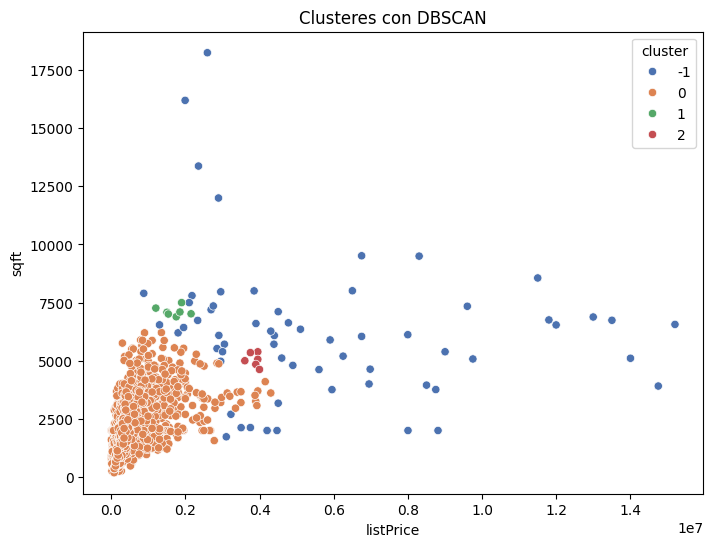

In [160]:
#graficacion del conjunto de datos
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='listPrice',
    y='sqft',
    hue='cluster',
    data=dataset_clustered,
    palette='deep')
plt.title('Clusteres con DBSCAN')
plt.xlabel="Precio de lista"
plt.ylabel="Tamano de la propiedad"
plt.show()